In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Local packages
from etc.hamiltonian import Hamiltonian
from etc_utils.graph_models import *
from etc_utils.phase_diagrams import *

### Hamiltonian Equation
 We pretend to find the minimun for a given set of nodes k and parameters $\mu/\gamma$

$$
H(S) = \sum_{j<i}-\mu A_{ij} s_i s_j + \gamma \frac{s_i s_j (1-A_{ij})}{d_{i,j}²}
$$


### Import all graphs examples
Once this is predifine we upload the example graphs 

In [2]:
Gs = get_graphs_list()

In [ ]:
def plot_phase_diagram(result: dict, *, cmap='viridis', interpolation='bilinear',
                        show_contours=True, contour_levels=8, annotate_crit=True,
                        save_path: str = None):
    """
    Improved phase-diagram plotting helper.

    Features:
    - Sorts keys for consistent axes
    - Better x/y ticks and labels (uses raw strings to avoid escape warnings)
    - Optional contour overlay and automatic critical-point highlighting
    - Optional saving and returns (fig, ax)
    """
    if not result:
        raise ValueError("The result dictionary is empty.")

    # Use sorted keys so axes increase monotonically
    k_values = sorted(list(result.keys()))
    if not all(isinstance(k, (int, float)) for k in k_values):
        raise ValueError("Keys of the result dictionary must be numeric (e.g., int or float).")

    scale_values = sorted(list(result[k_values[0]].keys()))
    if not all(isinstance(scale, (int, float)) for scale in scale_values):
        raise ValueError("Scale values in the result dictionary must be numeric (e.g., int or float).")

    mu_gamma_list = []
    hmin_list = []
    for k in k_values:
        for scale in scale_values:
            ratio, hmin = result[k][scale]
            mu_gamma_list.append(ratio)
            hmin_list.append(hmin)

    # Reshape into 2D arrays with shape (len(k_values), len(scale_values))
    try:
        mu_gamma_arr = np.array(mu_gamma_list).reshape(len(k_values), len(scale_values))
        hmin_arr = np.array(hmin_list).reshape(len(k_values), len(scale_values))
    except ValueError as e:
        raise ValueError(
            "Mismatch in the dimensions of the result data. Ensure the data is consistent."
            ) from e

    # x coordinates (one value per column), y coordinates (one per row)
    x_vals = mu_gamma_arr[0, :].astype(float)
    y_vals = np.array(k_values, dtype=float)

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Use imshow for a quick heatmap, but set extent so x axis maps to mu/gamma values
    extent = [x_vals.min(), x_vals.max(), y_vals.min() - 0.5, y_vals.max() + 0.5]
    im = ax.imshow(hmin_arr, aspect='auto', origin='lower', interpolation=interpolation,
                   cmap=cmap, extent=extent)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('H_min')

    # Axis labels (use raw strings to avoid invalid escape sequence warnings)
    ax.set_xlabel(r'$\mu / \gamma$')
    ax.set_ylabel(r'$k$')
    ax.set_title('Phase Diagram')

    # X ticks: one per scale column (show at most 12 labels to avoid overlap)
    max_xticks = 12
    if len(x_vals) <= max_xticks:
        xt_positions = x_vals
        xt_labels = [f'{v:.3g}' for v in x_vals]
    else:
        idxs = np.linspace(0, len(x_vals) - 1, max_xticks, dtype=int)
        xt_positions = x_vals[idxs]
        xt_labels = [f'{v:.3g}' for v in x_vals[idxs]]
    ax.set_xticks(xt_positions)
    ax.set_xticklabels(xt_labels, rotation=45, ha='right')

    # Y ticks: show the k values
    ax.set_yticks(y_vals)
    ax.set_yticklabels([str(int(v)) if float(v).is_integer() else f'{v:.2g}' for v in y_vals])

    # Optional contour overlay to highlight level sets
    if show_contours:
        Xc, Yc = np.meshgrid(x_vals, y_vals)
        cs = ax.contour(Xc, Yc, hmin_arr, levels=contour_levels, colors='white', linewidths=0.7, alpha=0.8)
        ax.clabel(cs, inline=True, fontsize=8, fmt='%.2g')

    # Annotate critical points using gradient along k (rows)
    if annotate_crit:
        grad = np.gradient(hmin_arr, axis=0)
        thresh = np.percentile(np.abs(grad), 95)
        crit_idx = np.where(np.abs(grad) > thresh)
        if crit_idx[0].size > 0:
            xs = x_vals[crit_idx[1]]
            ys = y_vals[crit_idx[0]]
            ax.scatter(xs, ys, c='red', s=18, label='Critical (top 5%)')
            ax.legend(loc='upper right')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    return fig, ax

1. First example
## Barbell graph (c=25, p=5)
* Nodes: $n=25$
* Edges: $e = 96$
##### Is the composition of 2 chiques connected by a line

Uncomment the line below to visualize the graph

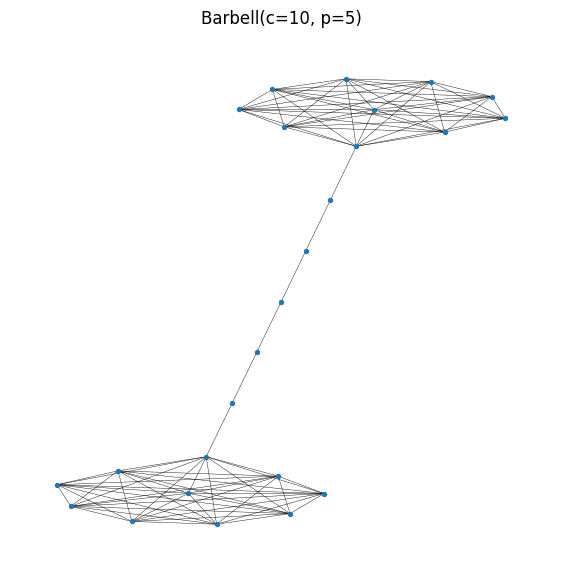

In [5]:
show_graph(Gs[0][1], title=Gs[0][0])

### Hamiltonian and graph atributes
$$\mu = 1 - \rho$$
where $\rho$ is
$$\rho = \frac{2e}{n(n-1)}$$

In [6]:
H1 = Hamiltonian(Gs[0][1])
# parameter mu predefined
mu=H1.mu_density_aware(G=Gs[0][1])
# parameter gamma predefined
gamma=H1.gamma_balancer()
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[0][1]))
# Inverse of distance matrix upper triangle
D2 = H1.Dinv2_triu

In [7]:
mu

0.6799999999999999

In [8]:
gamma

30.117647058823533

In [9]:
mu/gamma

0.022578124999999994

In [10]:
G1_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H1,
    mu=mu,
    gamma=gamma,
    kmax=int(7),
    scale_min=float(0.2500),
    scale_max=float(1.7500),
    scale_steps=float(0.2500),
    k_steps=1
)

/tmp/ipykernel_161533/1632035461.py:49: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(hmin_arr, aspect='auto', origin='lower', interpolation=interpolation,


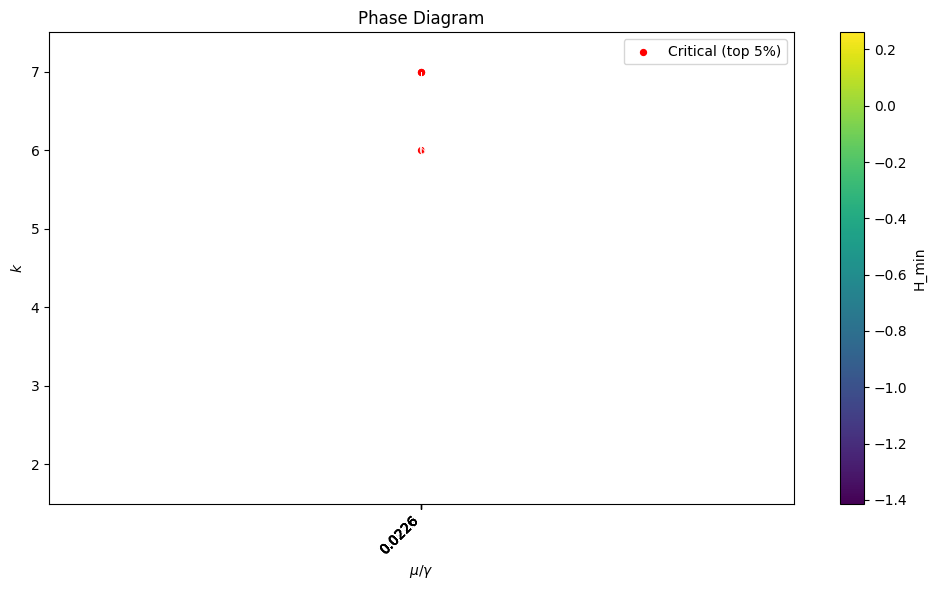

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram'}, xlabel='$\\mu / \\gamma$', ylabel='$k$'>)

In [11]:
plot_phase_diagram(G1_pd)

In [7]:
#save values of G1_pd
np.save('G1_pd.npy', G1_pd)

In [ ]:
G1_pd = np.load('G1_pd.npy', allow_pickle=True)

In [8]:
# # Compute gradients to identify critical points
# hmin_gradients = np.gradient(hmin_values, axis=0)
# critical_points = np.abs(hmin_gradients) > np.percentile(np.abs(hmin_gradients), 95)  # Top 5% changes

# # Overlay critical points on the phase diagram
# plt.figure(figsize=(10, 6))
# plt.imshow(hmin_values, aspect='auto', origin='lower',
#            extent=[mu_gamma_ratios.min(), mu_gamma_ratios.max(),
#                   min(k_values), max(k_values)], cmap='viridis')
# plt.colorbar(label='H_min')
# plt.xlabel('$\mu / \gamma$')
# plt.ylabel('$k$')
# plt.title('Phase Diagram with Critical Points')

# # Highlight critical points
# critical_k, critical_mu_gamma = np.where(critical_points)
# plt.scatter(mu_gamma_ratios[critical_k, critical_mu_gamma],
#             np.array(k_values)[critical_k], color='red', s=10, label='Critical Points')
# plt.legend()
# plt.show()

2. Second Example
## Balance Tree (ramifications=3, height=4)
* Nodes: $n = 121$
* Edges: $e = 120$
##### The left and right subtrees of any node are the same height

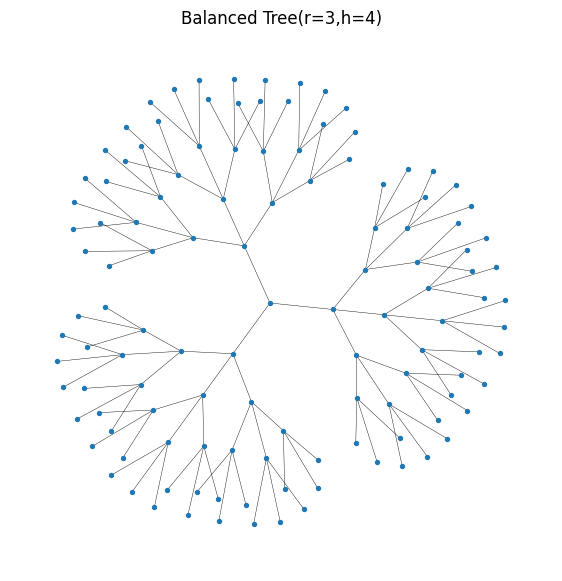

In [19]:
show_graph(Gs[4][1], title=Gs[4][0])

## Random Partition communities
* Nodes: $n = 45$
* Edges: $e = 283$
#### A graph of communities with sizes defined by s in sizes. 

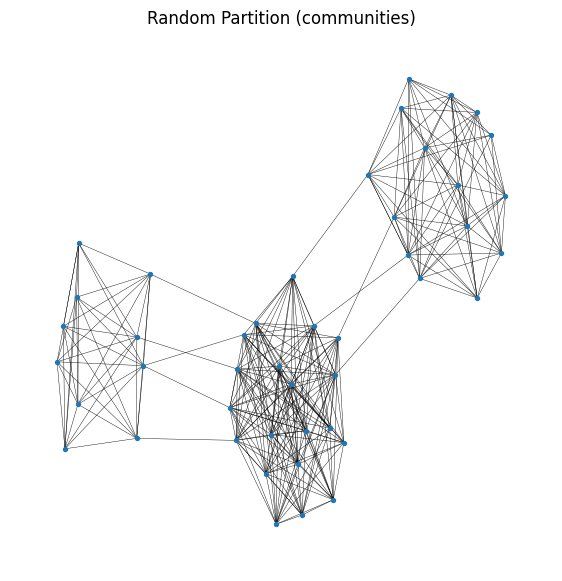

In [23]:
show_graph(Gs[7][1], title=Gs[7][0])

In [24]:
H7 = Hamiltonian(Gs[7][1])
# parameter mu predefined
mu=H7.mu_density_aware(G=Gs[7][1])
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[7][1]))
# Inverse of distance matrix upper triangle
D2 = H7.Dinv2_triu

In [25]:
G7_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H7,
    mu=mu,
    kmax=int(15),
    scale_max=int(15),
    scale_steps=1,
    k_steps=1
)

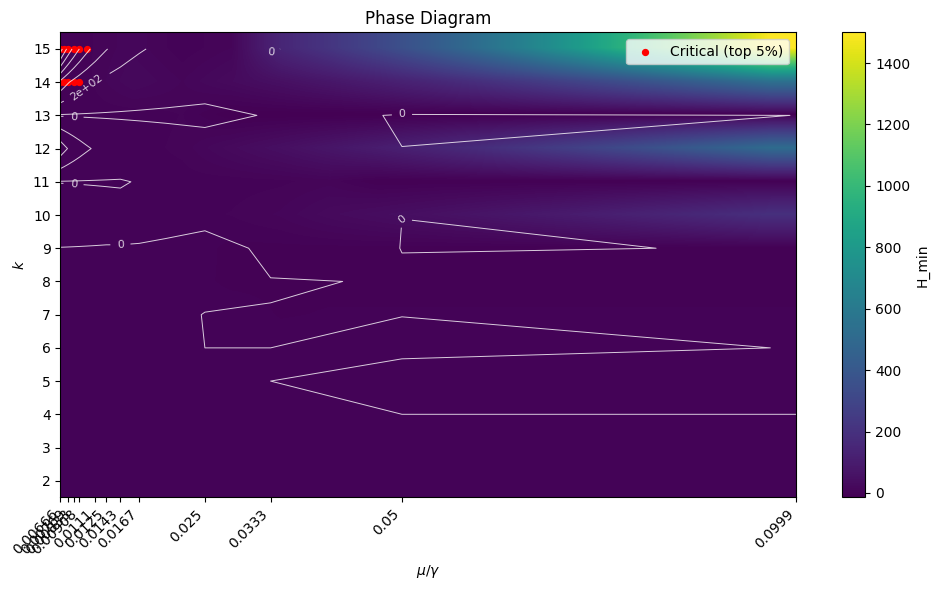

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram'}, xlabel='$\\mu / \\gamma$', ylabel='$k$'>)

In [26]:
plot_phase_diagram(G7_pd)

## Erdos-Renyi (n=80, p=0.05)
* Nodes: $n = 80$
* Edges: $e = 156$
##### A random graph which connects each pair of nodes {i,j} with probability p, independent

In [27]:
H6 = Hamiltonian(Gs[6][1])
# parameter mu predefined
mu=H6.mu_density_aware(G=Gs[6][1])
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[6][1]))
# Inverse of distance matrix upper triangle
D2 = H6.Dinv2_triu

In [28]:
G6_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H6,
    mu=mu,
    kmax=int(35),
    scale_max=int(35),
    scale_steps=1,
    k_steps=1
)

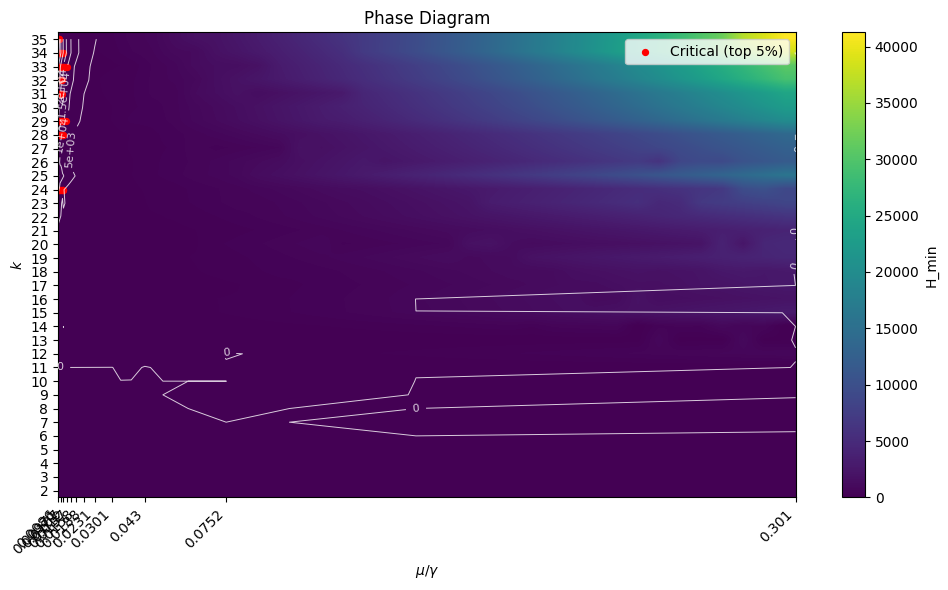

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram'}, xlabel='$\\mu / \\gamma$', ylabel='$k$'>)

In [29]:
plot_phase_diagram(G6_pd)

## 6D Regular (nodes=50, degree=6)
* Nodes: $n = 50$
* Edges: $e = 150$
##### Regular graph with 50 nodes where all nodes have degree 6

In [30]:
H17 = Hamiltonian(Gs[-3][1])
# parameter mu predefined
mu=H17.mu_density_aware(G=Gs[-3][1])
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[-3][1]))
# Inverse of distance matrix upper triangle
D2 = H17.Dinv2_triu

In [31]:
G17_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H17,
    mu=mu,
    kmax=int(20),
    scale_max=int(20),
    scale_steps=1,
    k_steps=1
)

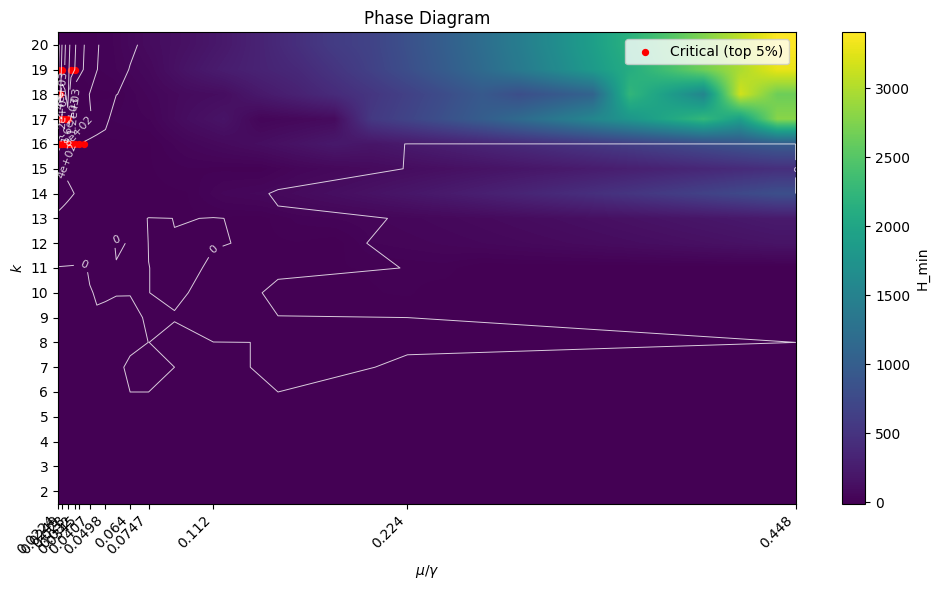

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Phase Diagram'}, xlabel='$\\mu / \\gamma$', ylabel='$k$'>)

In [7]:
plot_phase_diagram(G17_pd)

In [32]:
from matplotlib.colors import TwoSlopeNorm, SymLogNorm

def plot_phase_diagram(result: dict, *, cmap='viridis',
                       norm='symlog', linthresh=1.0,
                       show_contours=True, contour_levels=None,
                       annotate_crit=True, crit_percentile=95,
                       normalize=False, # use expectations to scale
                       E_T1=None, E_T2=None,  # dicts: E_T1[k], E_T2[k]
                       r_anchor=None,  # e.g. r0 = mu/gamma0 vertical line
                       save_path: str=None):

    # ---- unpack to arrays (same as yours) ----
    k_vals = sorted(result.keys())
    r_vals = sorted(next(iter(result.values())).keys())  # r = mu/gamma
    H = np.array([ [ result[k][r][1] for r in r_vals ] for k in k_vals ], dtype=float)

    # optional normalization (per k) to make terms comparable
    if normalize:
        if E_T1 is None or E_T2 is None:
            raise ValueError("Provide E_T1[k], E_T2[k] for normalization.")
        Hn = np.empty_like(H)
        for i,k in enumerate(k_vals):
            denom = (E_T1[k] if E_T1[k]!=0 else 1.0)
            # scale both terms comparably; assume H = -mu*T1 + gamma*T2 available only as H.
            # If you stored T1,T2, use them directly; else do a simple per-row z-scale:
            Hn[i,:] = (H[i,:] - np.median(H[i,:])) / (np.std(H[i,:]) + 1e-9)
        H = Hn

    # ---- choose color normalization ----
    if norm == 'two-slope':
        vmin, vmax = np.nanpercentile(H, 2), np.nanpercentile(H, 98)
        vmin = min(vmin, -1e-9); vmax = max(vmax, 1e-9)
        norm_obj = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    else:
        # symmetric log so both sides of zero are visible
        vmax = np.nanpercentile(np.abs(H), 98)
        norm_obj = SymLogNorm(linthresh=linthresh, vmin=-vmax, vmax=vmax)

    # ---- plot with pcolormesh ----
    R, K = np.meshgrid(r_vals, k_vals)
    fig, ax = plt.subplots(figsize=(10,6))
    h = ax.pcolormesh(R, K, H, shading='nearest', cmap=cmap, norm=norm_obj)
    cbar = fig.colorbar(h, ax=ax); cbar.set_label('H_min' + (' (normalized)' if normalize else ''))

    ax.set_xlabel(r'$\mu/\gamma$'); ax.set_ylabel(r'$k$'); ax.set_title('Phase Diagram')

    # ---- contours (include zero) ----
    if show_contours:
        if contour_levels is None:
            # include zero explicitly
            qs = np.linspace(10, 90, 5)
            levels = list(np.percentile(H[~np.isnan(H)], qs)) + [0.0]
            levels = sorted(set(levels))
        else:
            levels = contour_levels
        cs = ax.contour(R, K, H, levels=levels, colors='white', linewidths=0.8, alpha=0.9)
        ax.clabel(cs, inline=True, fontsize=8, fmt='%g')
        # bold 0-contour
        if 0.0 in cs.levels:
            i0 = list(cs.levels).index(0.0)
            for c in cs.collections[i0].get_paths():
                ax.plot([],[])  # placeholder to avoid tight_layout bug
            for seg in cs.collections[i0].get_segments():
                ax.plot(seg[:,0], seg[:,1], color='black', lw=2, alpha=0.9)

    # ---- critical ridge via 2D gradient magnitude ----
    if annotate_crit:
        dK, dR = np.gradient(H, axis=0), np.gradient(H, axis=1)
        G = np.hypot(dK, dR)
        thr = np.nanpercentile(G, crit_percentile)
        ii, jj = np.where(G >= thr)
        ax.scatter(np.array(r_vals)[jj], np.array(k_vals)[ii], s=14, c='red', label=f'Critical ridge (>{crit_percentile}%)')
        ax.legend(loc='upper left')

    # ---- anchor line at r0 = mu/gamma0 if provided ----
    if r_anchor is not None:
        ax.axvline(r_anchor, color='orange', lw=1.8, ls='--', label=r'$r_0$ balance')
        ax.legend(loc='upper right')

    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()
    return fig, ax

AttributeError: 'QuadContourSet' object has no attribute 'collections'

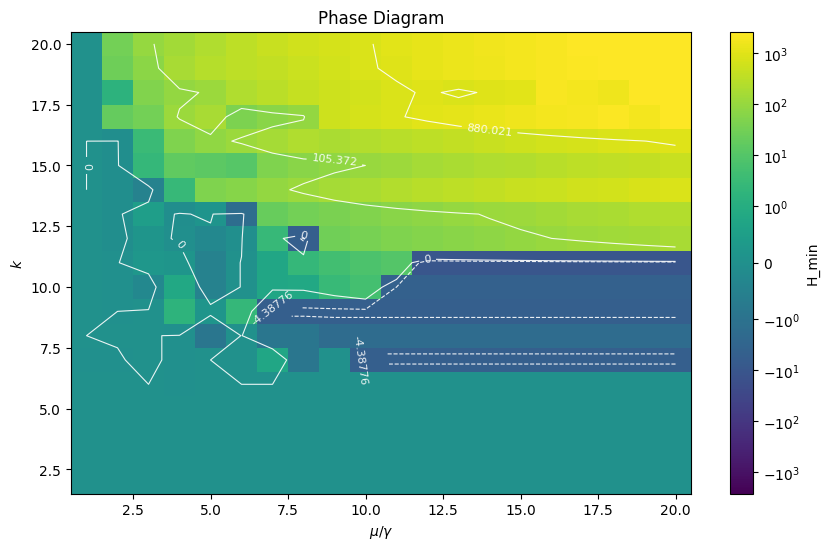

In [33]:
plot_phase_diagram(G17_pd)

In [ ]:
plot_phase_diagram(G7_pd)

NameError: name 'G7_pd' is not defined